In [1]:
# ============================================================
# Cell 1: Setup Check
# ============================================================

import subprocess
import sys

# Check required packages
packages = {
    "cv2": "opencv-python",
    "numpy": "numpy", 
    "matplotlib": "matplotlib",
    "mediapipe": "mediapipe",
}

print("📦 Package Check:")

all_ok = True
for module, pip_name in packages.items():
    try:
        mod = __import__(module)
        ver = getattr(mod, "__version__", "?")
        print(f"  ✅ {pip_name}: {ver}")
    except ImportError:
        print(f"  ❌ {pip_name}: Not installed")
        print(f"     → pip install {pip_name}")
        all_ok = False

if all_ok:
    print("\n✅ All packages OK!")
else:
    print("\n⚠️ Some packages are not installed. Please install them using the commands above.")

📦 Package Check:
  ✅ opencv-python: 4.13.0
  ✅ numpy: 2.4.2
  ✅ matplotlib: 3.10.8
  ✅ mediapipe: 0.10.32

✅ All packages OK!


In [2]:
# ============================================================
# Cell 1: Setup Check (with Auto-Install)
# ============================================================

import subprocess
import sys

# Check required packages
packages = {
    "cv2": "opencv-python",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "mediapipe": "mediapipe",
}

print("📦 Package Check:")

missing_packages = []
all_ok = True

for module, pip_name in packages.items():
    try:
        mod = __import__(module)
        ver = getattr(mod, "__version__", "?")
        print(f"  ✅ {pip_name}: {ver}")
    except ImportError:
        print(f"  ❌ {pip_name}: Not installed")
        missing_packages.append(pip_name)
        all_ok = False

if all_ok:
    print("\n✅ All packages are OK!")
else:
    print(f"\n⚠️ Missing packages: {', '.join(missing_packages)}")
    user_input = input("\nInstall automatically? (y/n): ")

    if user_input.lower() == "y":
        print("\n🔧 Installing...")
        for package in missing_packages:
            print(f"  → Installing {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print("\n✅ Installation complete! Please restart the kernel.")
    else:
        print("\nPlease install manually:")
        print(f"  pip install {' '.join(missing_packages)}")

📦 Package Check:
  ✅ opencv-python: 4.13.0
  ✅ numpy: 2.4.2
  ✅ matplotlib: 3.10.8
  ✅ mediapipe: 0.10.32

✅ All packages are OK!


In [3]:
# ============================================================
# Cell 2: Download Model Files
# ============================================================
# 
# To use MediaPipe Pose, you need "model files".
# Model file = Data corresponding to the AI's "brain" (trained weights)
#
# 3 variants:
#   Lite (6MB):  Fast but low accuracy
#   Full (15MB): Balanced
#   Heavy (30MB): Slow but high accuracy ← Recommended for rugby analysis

import os
import urllib.request

MODEL_DIR = "models"
MODEL_PATH = os.path.join(MODEL_DIR, "pose_landmarker_heavy.task")
MODEL_URL = ("https://storage.googleapis.com/mediapipe-models/"
             "pose_landmarker/pose_landmarker_heavy/float16/latest/"
             "pose_landmarker_heavy.task")

os.makedirs(MODEL_DIR, exist_ok=True)

if os.path.exists(MODEL_PATH):
    size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
    print(f"✅ Model file found: {MODEL_PATH} ({size_mb:.1f} MB)")
else:
    print(f"⬇️ Downloading model...")
    print(f"   URL: {MODEL_URL}")
    print(f"   Save path: {MODEL_PATH}")
    try:
        urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
        size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
        print(f"✅ Download complete! ({size_mb:.1f} MB)")
    except Exception as e:
        print(f"❌ Download failed: {e}")


✅ Model file found: models\pose_landmarker_heavy.task (29.2 MB)


In [4]:
# ============================================================
# Process a single image with MediaPipe ★Core★
# ============================================================
#
# This is the main part.
# Pass one image to MediaPipe Pose and get keypoints.
#
# Processing flow:
#   Image (BGR) → RGB conversion → MediaPipe Image → Run detection → Get results
#
# ★ This is the most important code in this section.

import mediapipe as mp
import numpy as np
import cv2

# MediaPipe Pose setup
BaseOptions = mp.tasks.BaseOptions  # Used to specify the model file
PoseLandmarker = mp.tasks.vision.PoseLandmarker  # Pose detector class
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions  # Configuration
RunningMode = mp.tasks.vision.RunningMode  # Operation mode (image/video/live stream)

# Configure options
options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),  # Model file
    running_mode=RunningMode.IMAGE,  # Image mode (process one image at a time)
    num_poses=1,  # Maximum number of people to detect (1 is enough here)
    min_pose_detection_confidence=0.5,  # Minimum detection confidence (0.0–1.0)
    # Lower value = easier detection but more noise
)

print("Configuration:")
print(f"  Model: {MODEL_PATH}")
print("  Mode: IMAGE (single still image)")
print("  Max poses: 1")
print("  Min detection confidence: 0.5")


Configuration:
  Model: models\pose_landmarker_heavy.task
  Mode: IMAGE (single still image)
  Max poses: 1
  Min detection confidence: 0.5


In [5]:
IMAGE_PATH = "C:\\Users\\User\\OneDrive - National University of Singapore\\Pictures\\Screenshots\\Screenshot 2026-02-22 225246.png"
image = cv2.imread(IMAGE_PATH)

if image is None:
    print(f"❌ Failed to load image: {IMAGE_PATH}")
else:
    print(f"📷 Image loaded: {IMAGE_PATH}")
    print(f"   Size: {image.shape[1]}x{image.shape[0]} (width x height)")
    print(f"   Channels: {image.shape[2]} (BGR)")

    # ★ Important: OpenCV uses BGR, MediaPipe uses RGB
    # BGR = Blue-Green-Red order (OpenCV standard)
    # RGB = Red-Green-Blue order (common standard)

    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # BGR → RGB

    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)  # Convert to MediaPipe Image
    print("📷 Converted image to RGB and created a MediaPipe Image.")

    # ★★★ Run detection ★★★
    with PoseLandmarker.create_from_options(options) as landmarker:
        result = landmarker.detect(mp_image)

    if result.pose_landmarks:
        print("✅ Keypoints detected!")
        print(f"   Number of people detected: {len(result.pose_landmarks)}")
    else:
        print("❌ Failed to detect keypoints.")

📷 Image loaded: C:\Users\User\OneDrive - National University of Singapore\Pictures\Screenshots\Screenshot 2026-02-22 225246.png
   Size: 971x673 (width x height)
   Channels: 3 (BGR)
📷 Converted image to RGB and created a MediaPipe Image.
✅ Keypoints detected!
   Number of people detected: 1


In [6]:
# ============================================================
# Inspect detection result details
# ============================================================
#
# What is inside result.pose_landmarks?
# → A list of 33 NormalizedLandmark objects

# MediaPipe keypoint name mapping
KEYPOINT_NAMES = {
    0: "nose", 1: "left_eye_inner", 2: "left_eye", 3: "left_eye_outer",
    4: "right_eye_inner", 5: "right_eye", 6: "right_eye_outer",
    7: "left_ear", 8: "right_ear", 9: "mouth_left", 10: "mouth_right",
    11: "left_shoulder", 12: "right_shoulder",
    13: "left_elbow", 14: "right_elbow",
    15: "left_wrist", 16: "right_wrist",
    17: "left_pinky", 18: "right_pinky",
    19: "left_index", 20: "right_index",
    21: "left_thumb", 22: "right_thumb",
    23: "left_hip", 24: "right_hip",
    25: "left_knee", 26: "right_knee",
    27: "left_ankle", 28: "right_ankle",
    29: "left_heel", 30: "right_heel",
    31: "left_foot_index", 32: "right_foot_index"
}

if result.pose_landmarks:
    landmarks = result.pose_landmarks[0]  # First detected person
    
    print("📋 All 33 detected keypoints:")
    print("=" * 70)
    print(f"{'#':>3s}  {'Name':20s}  {'x':>8s}  {'y':>8s}  {'z':>8s}  {'Conf.':>6s}")
    print("-" * 70)
    
    for i, lm in enumerate(landmarks):
        name = KEYPOINT_NAMES.get(i, f"point_{i}")
        # ★ This is the AI output: normalized coordinates (x, y, z) and visibility
        print(f"{i:3d}  {name:20s}  {lm.x:8.4f}  {lm.y:8.4f}  {lm.z:8.4f}  {lm.visibility:6.3f}")
    
    print()
    print("💡 Meaning of each column:")
    print("  x: Normalized X coordinate (0.0=left edge, 1.0=right edge)")
    print("  y: Normalized Y coordinate (0.0=top edge, 1.0=bottom edge)")
    print("  z: Depth (relative to hips as origin, closer to camera = negative)")
    print("  Conf.: How reliable the point is (0.0~1.0)")
else:
    print("⚠️ No detection result found, so this section is skipped.")
    print("   Please run again with a real person image.")


📋 All 33 detected keypoints:
  #  Name                         x         y         z   Conf.
----------------------------------------------------------------------
  0  nose                    0.4787    0.2382   -0.2296   1.000
  1  left_eye_inner          0.4814    0.2123   -0.2400   1.000
  2  left_eye                0.4858    0.2103   -0.2404   1.000
  3  left_eye_outer          0.4899    0.2083   -0.2403   1.000
  4  right_eye_inner         0.4733    0.2164   -0.2194   1.000
  5  right_eye               0.4712    0.2149   -0.2198   1.000
  6  right_eye_outer         0.4692    0.2134   -0.2199   1.000
  7  left_ear                0.5049    0.1936   -0.1981   1.000
  8  right_ear               0.4732    0.2060   -0.1001   1.000
  9  mouth_left              0.4903    0.2334   -0.2012   1.000
 10  mouth_right             0.4779    0.2415   -0.1756   1.000
 11  left_shoulder           0.5716    0.2084   -0.2063   1.000
 12  right_shoulder          0.4590    0.2435    0.0428   1.000
 13 

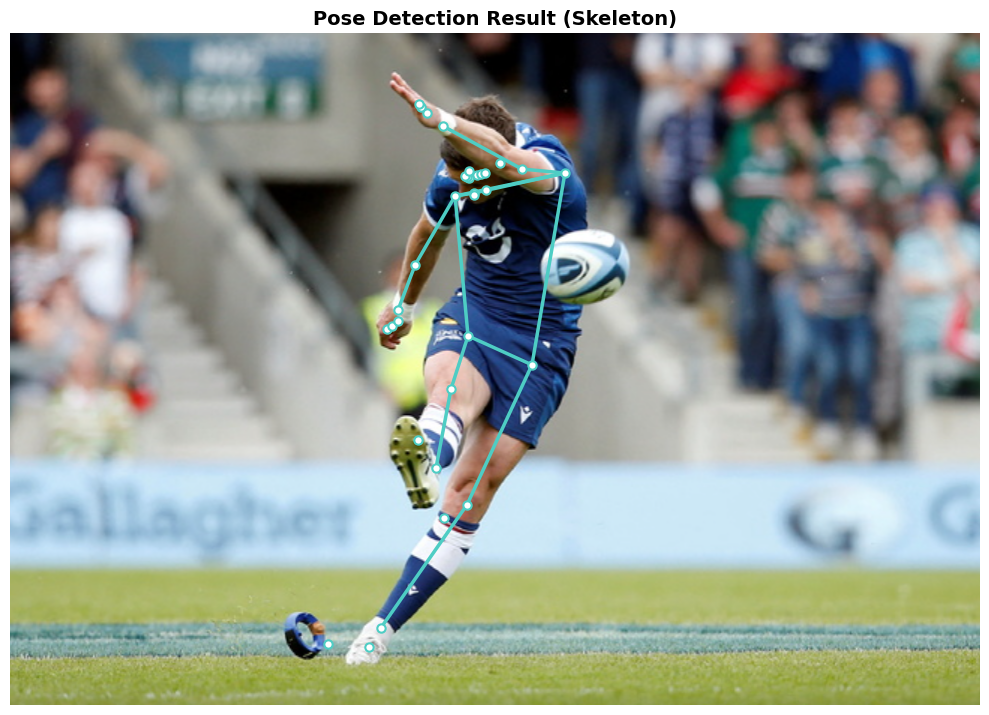

✅ Skeleton drawing complete!
   → You can visually verify whether detection worked correctly.


In [7]:
# ============================================================
# Visually verify detection results using skeleton drawing
# ============================================================

import matplotlib.pyplot as plt

# Connection definitions (skeleton structure)
connections = [
    ("nose", "left_shoulder"),
    ("nose", "right_shoulder"),
    ("left_shoulder", "right_shoulder"),
    ("left_shoulder", "left_elbow"),
    ("left_elbow", "left_wrist"),
    ("right_shoulder", "right_elbow"),
    ("right_elbow", "right_wrist"),
    ("left_shoulder", "left_hip"),
    ("right_shoulder", "right_hip"),
    ("left_hip", "right_hip"),
    ("left_hip", "left_knee"),
    ("left_knee", "left_ankle"),
    ("right_hip", "right_knee"),
    ("right_knee", "right_ankle"),
]

# Function to convert normalized coordinates to pixel coordinates
def normalize_to_pixel(lm, img_width, img_height):
    return int(lm.x * img_width), int(lm.y * img_height)

# Store keypoints in a dictionary
keypoints = {}
img_height, img_width = image.shape[:2]

for name, idx in {v: k for k, v in KEYPOINT_NAMES.items()}.items():
    lm = landmarks[idx]
    x, y = normalize_to_pixel(lm, img_width, img_height)
    keypoints[name] = (x, y)

# Draw skeleton
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

# Draw connection lines
for (name_a, name_b) in connections:
    if name_a in keypoints and name_b in keypoints:
        xa, ya = keypoints[name_a]
        xb, yb = keypoints[name_b]
        ax.plot([xa, xb], [ya, yb], '-', color='#4ecdc4', linewidth=2.5)

# Draw keypoints
for name, (x, y) in keypoints.items():
    ax.plot(x, y, 'o', markersize=6, color='white',
            markeredgecolor='#4ecdc4', markeredgewidth=1.5)

ax.set_title("Pose Detection Result (Skeleton)", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("✅ Skeleton drawing complete!")
print("   → You can visually verify whether detection worked correctly.")

In [8]:
# ============================================================
# Connect to Step 1 knowledge (coordinates → angles)
# ============================================================
#
# Use the normalized coordinates output by AI
# and apply the angle calculation learned in Step 1.

def calculate_angle(a, b, c):
    ba = a - b
    bc = c - b
    cosine_theta = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)  # avoid division by zero
    cosine_theta = np.clip(cosine_theta, -1.0, 1.0)
    return float(np.degrees(np.arccos(cosine_theta)))

if result.pose_landmarks:
    Landmarks = result.pose_landmarks[0]
    
    def get_point(name):
        # Function to get coordinates from keypoint name
        # name -> index -> Landmark -> (x, y, z)
        idx = {v: k for k, v in KEYPOINT_NAMES.items()}.get(name)
        if idx is not None:
            lm = Landmarks[idx]
            return np.array([lm.x, lm.y])
        return None
    
    # Calculate joint angles
    print("📐 Angle calculation examples:")
    print("=" * 50)
    
    angles_to_calc = {
        "Right Elbow": ("right_shoulder", "right_elbow", "right_wrist"),
        "Left Elbow": ("left_shoulder", "left_elbow", "left_wrist"),
        "Right Knee": ("right_hip", "right_knee", "right_ankle"),
        "Left Knee": ("left_hip", "left_knee", "left_ankle"),
    }
    
    for joint_name, (a_name, b_name, c_name) in angles_to_calc.items():
        a = get_point(a_name)
        b = get_point(b_name)
        c = get_point(c_name)
        
        if a is not None and b is not None and c is not None:
            angle = calculate_angle(a, b, c)
            print(f"  {joint_name}: {angle:.1f}°")
        else:
            print(f"  {joint_name}: Cannot calculate because coordinates are missing")
            
    print()
    print("✅ AI output → Step 1 calculation was used directly!")

📐 Angle calculation examples:
  Right Elbow: 171.7°
  Left Elbow: 148.7°
  Right Knee: 174.2°
  Left Knee: 171.6°

✅ AI output → Step 1 calculation was used directly!


In [9]:
# ============================================================
# Basic pattern for video processing
# ============================================================
#
# Video processing = just loop through this pattern:
#
#   while frames remain in the video:
#       Get one frame (one image)
#       Detect keypoints with AI
#       Calculate angles
#       Save results
#
# ★ This pattern is the same for both MediaPipe and YOLO

import cv2

VIDEO_PATH = r"C:\Users\User\OneDrive - National University of Singapore\Videos\Clipchamp\Video Project 5\Assets\Video tackling.mp4"  # tackling

print(f"\n📹 Basic pattern for video processing:")
print("=" * 50)

cap = cv2.VideoCapture(VIDEO_PATH)

fps = 0.0
total = 0
w = 0
h = 0

if not cap.isOpened():
	print(f"❌ Cannot open video file: {VIDEO_PATH}")
else:
	fps = cap.get(cv2.CAP_PROP_FPS)
	total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
	w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
	h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

cap.release()

print("Video info:")
print(f"  File: {VIDEO_PATH}")
print(f"  Resolution: {w}x{h}")
print(f"  FPS: {fps:.1f} ({fps:.0f} frames per second)")
print(f"  Total frames: {total}")
print(f"  Duration: {total/fps:.1f} s")


📹 Basic pattern for video processing:
Video info:
  File: C:\Users\User\OneDrive - National University of Singapore\Videos\Clipchamp\Video Project 5\Assets\Video tackling.mp4
  Resolution: 3840x2160
  FPS: 30.0 (30 frames per second)
  Total frames: 126
  Duration: 4.2 s


In [10]:
# # 🏉 Step 3: Analyze a Real Video and Create Graphs
#
# ## How this connects to Steps 1 and 2
# ```
# What you learned in Step 1:            What you learned in Step 2:
# ├── Coordinates (x, y)                 ├── MediaPipe setup
# ├── calculate_angle()                  ├── Processing a single image
# └── Meaning of time-series graphs      └── Detection result structure (33 keypoints)
#
#               ↓ Combine them ↓
#
# Step 3 (this step):
# ├── Process a video frame by frame (repeat Step 2)
# ├── Compute joint angles for all frames (repeat Step 1)
# ├── [New] Compute angular velocity
# ├── [New] Compute trunk inclination
# ├── [New] Compute joint speed
# ├── Create time-series graphs
# └── Export to CSV
# ```

print("🏉 Step 3: Analyze a real video and create graphs")
print("This step combines Step 1 (angle math) and Step 2 (MediaPipe detection) on full video data.")


🏉 Step 3: Analyze a real video and create graphs
This step combines Step 1 (angle math) and Step 2 (MediaPipe detection) on full video data.


In [11]:
# ============================================================
# Load libraries
# ============================================================
#
# Same libraries as Steps 1 and 2 + csv (for file export)

import numpy as np
import matplotlib
matplotlib.use('Agg')  # For running outside Jupyter; not needed in Jupyter
import matplotlib.pyplot as plt
import cv2
import os
import csv
import time

print("✅ Library imports complete")


✅ Library imports complete


In [12]:
# ============================================================
# Cell 2: Re-listing functions created in Step 1 (Preparing tools)
# ============================================================

def calculate_angle(a, b, c):
    """
    [Learned in Step 1 Cell 7]
    Calculate the angle θ at vertex B from 3 points A, B, C.

    Math:
      BA = A - B        ← Vector from B to A
      BC = C - B        ← Vector from B to C
      cos(θ) = (BA·BC) / (|BA|×|BC|)
      θ = arccos(cos(θ))

    Usage:
      angle = calculate_angle(shoulder_coords, elbow_coords, wrist_coords)
      → Returns the elbow angle
    """
    ba = a - b
    bc = c - b
    cos_theta = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_theta)))


def calculate_angular_velocity(angles, fps):
    """
    [New] Function to calculate angular velocity

    ■ What is angular velocity?
      "How fast the angle is changing"

      Example: Knee angle during a kick
        Frame 10: 120° → Frame 12: 160°
        → 40° change in 2 frames (=0.067 sec @ 30fps)
        → Angular velocity ≈ 600°/sec ← quite fast!

    ■ Calculation method (Central Difference Method):
      ω[i] = (θ[i+1] - θ[i-1]) / (2 × Δt)

      Why "central" difference?
      → More robust to noise than forward difference (θ[i+1]-θ[i])/Δt
      → Uses both previous and next frames, giving higher accuracy (O(Δt²))

    ■ Use cases:
      - Kick: Large angular velocity at knee → Powerful kick
      - Pass: Large angular velocity at elbow → Fast arm swing

    Parameters:
        angles: List of angles [θ0, θ1, θ2, ...] (degrees)
        fps: Video FPS (frames per second)

    Returns:
        List of angular velocities [ω0, ω1, ω2, ...] (degrees/sec)
    """
    dt = 1.0 / fps # Time interval per frame (seconds)
    n = len(angles)
    
    if n < 2:
        return [0.0]*n
    
    velocities = [] 
    for i in range(n):
        if i == 0:
            # First frame: forward difference
            omega = (angles[1] - angles[0]) / dt
        elif i == n-1:
            # Last frame: backward difference
            omega = (angles[n-1] - angles[n-2]) / dt
        else:
            # Middle frames: central difference
            omega = (angles[i+1] - angles[i-1]) / (2 * dt)
        velocities.append(omega)
    return velocities

def calculate_joint_speed(positions, fps):
    """
    [New] Function to calculate joint movement speed

    ■ What is joint speed?
      "How far a joint moves in one second"

      Example: Wrist during a pass
        Frame 20: (0.3, 0.5) → Frame 21: (0.35, 0.48)
        → Moved (0.05, -0.02) in 1 frame
        → Distance = √(0.05² + 0.02²) = 0.054
        → Speed = 0.054 / (1/30) = 1.62 normalized units/sec

    ■ Calculation method:
      v[i] = ||p[i] - p[i-1]|| / Δt
      
      ||...|| = Euclidean distance = √((Δx)² + (Δy)²)

    ■ Use cases:
      - Pass: Wrist speed momentarily high
      - Kick: Ankle speed momentarily high (one foot only)
      - Tackle: Whole body slowly moving forward

    Parameters:
        positions: List of coordinates [[x0,y0], [x1,y1], ...]
        fps: FPS

    Returns:
        List of speeds [v0, v1, v2, ...] (normalized units/sec)
    """
    dt = 1.0 / fps
    speeds = [0.0] # First frame speed is 0
    
    for i in range(1, len(positions)):
        # Distance between 2 frames
        distance = np.linalg.norm(
            np.array(positions[i]) - np.array(positions[i-1])
        )
        speed = distance / dt
        speeds.append(speed)
    return speeds

def calculate_trunk_inclination(left_shoulder, right_shoulder, left_hip, right_hip):
    """
    [New] Function to calculate trunk inclination angle

    ■ What is trunk inclination?
      "How far forward the upper body is leaning"

      Upright = 0°, Forward lean = positive, Backward lean = negative

    ■ Calculation method:
      1. Shoulder midpoint = (left shoulder + right shoulder) / 2
      2. Hip midpoint = (left hip + right hip) / 2
      3. Trunk vector = shoulder midpoint - hip midpoint
      4. Inclination angle = arctan2(trunk vector x-component, -trunk vector y-component)

         Why arctan2?
         → Regular arctan can only return -90° to +90°
         → arctan2 covers the full range of -180° to +180°
         → Negating the y-component converts image coordinates (down is positive)
           to standard coordinates (up is positive)

    ■ Use cases:
      - Tackle: Forward lean > 30° → Tackle posture
      - Pass: 5° to 25° range → Slight body rotation
      - Kick: Slight backward lean → Maintaining balance

    Parameters:
        Each argument: numpy array [x, y]

    Returns:
        Inclination angle (degrees). Positive = forward lean, Negative = backward lean
    """
    # Calculate midpoints of shoulders and hips
    mid_shoulder = (np.array(left_shoulder) + np.array(right_shoulder)) / 2
    mid_hip = (np.array(left_hip) + np.array(right_hip)) / 2
    
    # Calculate trunk vector
    trunk_vector = mid_shoulder - mid_hip
    
    # Calculate inclination angle (arctan2 returns range of -180° to +180°)
    angle = np.degrees(np.arctan2(trunk_vector[0], -trunk_vector[1]))
    return float(angle)


print("✅ Analysis functions defined:")
print("   - calculate_angle()            : Joint angle (learned in Step 1)")
print("   - calculate_angular_velocity() : Angular velocity (new)")
print("   - calculate_joint_speed()      : Joint speed (new)")
print("   - calculate_trunk_inclination(): Trunk inclination (new)")


✅ Analysis functions defined:
   - calculate_angle()            : Joint angle (learned in Step 1)
   - calculate_angular_velocity() : Angular velocity (new)
   - calculate_joint_speed()      : Joint speed (new)
   - calculate_trunk_inclination(): Trunk inclination (new)


In [13]:
# ============================================================
# Cell 4: Video Preparation and Info Check
# ============================================================
#
# How to get a video if you don't have one:
#   - Search for rugby highlights on YouTube
#   - Trim to a 2–5 second clip (longer clips take more time to process)
#   - Download using yt-dlp or screen recording
#
# Recommended:
#   - Resolution: 720p or higher
#   - FPS: 30fps or higher
#   - Number of people: 1–2 people clearly visible
#   - Angle: Side view or diagonal front view

#VIDEO_PATH = r"C:\Users\User\OneDrive - National University of Singapore\Videos\Clipchamp\Video Project 6\Exports\Video_kicking.mp4" # kicking
VIDEO_PATH = r"C:\Users\User\OneDrive - National University of Singapore\Videos\Clipchamp\Video Project 5\Assets\Video tackling.mp4" # tackling

# Check video file
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    print(f"❌ Cannot open video file: {VIDEO_PATH}")
else:
    print(f"✅ Video file opened: {VIDEO_PATH}")

FPS = cap.get(cv2.CAP_PROP_FPS)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
WIDTH = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
DURATION = TOTAL_FRAMES / FPS if FPS > 0 else 0
cap.release()

print(f"\n📹 Video Info:")
print(f"  File:        {VIDEO_PATH}")
print(f"  Resolution:  {WIDTH} x {HEIGHT}")
print(f"  FPS:         {FPS:.1f}")
print(f"  Total Frames: {TOTAL_FRAMES}")
print(f"  Duration:    {DURATION:.2f} seconds")

✅ Video file opened: C:\Users\User\OneDrive - National University of Singapore\Videos\Clipchamp\Video Project 5\Assets\Video tackling.mp4

📹 Video Info:
  File:        C:\Users\User\OneDrive - National University of Singapore\Videos\Clipchamp\Video Project 5\Assets\Video tackling.mp4
  Resolution:  3840 x 2160
  FPS:         30.0
  Total Frames: 126
  Duration:    4.20 seconds


In [14]:
# Define joint angles to analyze (learned in Step 1)
# (Point A, Vertex B, Point C) → angle at B
JOINT_ANGLE_DEFS = {
    "right_elbow":  ("right_shoulder", "right_elbow", "right_wrist"),
    "left_elbow":   ("left_shoulder",  "left_elbow",  "left_wrist"),
    "right_knee":   ("right_hip",      "right_knee",  "right_ankle"),
    "left_knee":    ("left_hip",       "left_knee",   "left_ankle"),
    "right_shoulder": ("right_elbow",  "right_shoulder", "right_hip"),
    "left_shoulder":  ("left_elbow",   "left_shoulder",  "left_hip"),
    "right_hip":    ("right_shoulder", "right_hip",    "right_knee"),
    "left_hip":     ("left_shoulder",  "left_hip",     "left_knee"),
}

# Connections for skeleton drawing
SKELETON_CONNECTIONS = [
    ("nose", "left_shoulder"), ("nose", "right_shoulder"),
    ("left_shoulder", "right_shoulder"),
    ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),
    ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),
    ("left_shoulder", "left_hip"), ("right_shoulder", "right_hip"),
    ("left_hip", "right_hip"),
    ("left_hip", "left_knee"), ("left_knee", "left_ankle"),
    ("right_hip", "right_knee"), ("right_knee", "right_ankle"),
]

print("✅ MediaPipe setup complete")
print(f"   Model: {MODEL_PATH}")
print(f"   Number of joint angles to analyze: {len(JOINT_ANGLE_DEFS)}")
print(f"   Joint angle names to analyze: {list(JOINT_ANGLE_DEFS.keys())}")


✅ MediaPipe setup complete
   Model: models\pose_landmarker_heavy.task
   Number of joint angles to analyze: 8
   Joint angle names to analyze: ['right_elbow', 'left_elbow', 'right_knee', 'left_knee', 'right_shoulder', 'left_shoulder', 'right_hip', 'left_hip']


In [15]:
# ============================================================
# Cell 6: ★★★ Main analysis loop ★★★
# ============================================================
#
# This is the core of Step 3.
#
# What this does (line-by-line overview):
#   1. Open the video
#   2. Create a MediaPipe Landmarker in VIDEO mode
#   3. Process all frames in a while loop:
#      a. Read a frame
#      b. Convert BGR -> RGB
#      c. Run MediaPipe detection
#      d. Convert detection results to a keypoint dictionary
#      e. Compute joint angles
#      f. Compute trunk inclination
#      g. Record joint positions (used later for speed calculation)
#   4. After the loop, compute angular velocity and joint speed

# --- Variables to store results ---
# Dictionary to store angles for each frame
# "right_knee" -> [angle at frame 0, angle at frame 1, ...]
all_angles = {name: [] for name in JOINT_ANGLE_DEFS}

# List to store trunk inclination
all_trunk_incl = []

# Dictionary to store joint positions (for speed calculation later)
# "right_wrist" -> [[x0,y0], [x1,y1], ...]
speed_joints = ['right_wrist', 'left_wrist', 'right_ankle', 'left_ankle', 'nose']
all_positions = {name: [] for name in speed_joints}

# Timestamps
all_timestamps = []

# Detection success/failure counter
detected_frames = 0 

print("🏃 Starting analysis loop...")
print("=" * 60)

# --- Create MediaPipe Landmarker (VIDEO mode) ---
BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
RunningMode = mp.tasks.vision.RunningMode

options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    running_mode=RunningMode.VIDEO,  # Create in VIDEO mode
    num_poses=1,  # Maximum number of people to detect (up to 2 in this project)
    min_pose_detection_confidence=0.5,
    min_tracking_confidence=0.5,  # Enable tracking in VIDEO mode
)

landmarker = PoseLandmarker.create_from_options(options)

# --- Open video ---
cap = cv2.VideoCapture(VIDEO_PATH)
start_time = time.time()
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    # Compute timestamp
    timestamp = frame_idx / FPS
    all_timestamps.append(timestamp)
    
    # BGR -> RGB
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Convert to MediaPipe Image
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
    
    # ★ In VIDEO mode, use detect_for_video()
    # Arguments: (image, timestamp[ms])
    # Timestamp must be monotonically increasing
    timestamp_ms = int(frame_idx * 1000 / FPS)
    result = landmarker.detect_for_video(mp_image, timestamp_ms)
    
    # Process detection result
    if result.pose_landmarks and len(result.pose_landmarks) > 0:
        detected_frames += 1
        landmarks = result.pose_landmarks[0]
        
        # Convert keypoints to dictionary
        kp = {}
        kp_visibility = {}
        for idx, lm in enumerate(landmarks):
            name = KEYPOINT_NAMES[idx]
            kp[name] = np.array([lm.x, lm.y])  # Normalized coordinates
            kp_visibility[name] = lm.visibility
            
        # Compute joint angles
        for angle_name, (a_name, b_name, c_name) in JOINT_ANGLE_DEFS.items():
            if (a_name in kp and b_name in kp and c_name in kp
                and kp_visibility[a_name] > 0.3
                and kp_visibility[b_name] > 0.3
                and kp_visibility[c_name] > 0.3):
                angle = calculate_angle(kp[a_name], kp[b_name], kp[c_name])
            else:
                # If not detected: use previous value, otherwise 180° (extension)
                angle = all_angles[angle_name][-1] if all_angles[angle_name] else 180.0
            all_angles[angle_name].append(angle)
            
        # Compute trunk inclination
        required = ["left_shoulder", "right_shoulder", "left_hip", "right_hip"]
        if all(name in kp for name in required):
            incl = calculate_trunk_inclination(
                kp["left_shoulder"], kp["right_shoulder"],
                kp["left_hip"], kp["right_hip"]
            )
        else:
            incl = all_trunk_incl[-1] if all_trunk_incl else 0.0
        all_trunk_incl.append(incl)
        
        # Record joint positions
        for join_name in speed_joints:
            if join_name in kp:
                all_positions[join_name].append(kp[join_name])
            elif all_positions[join_name]:
                # Use previous position
                all_positions[join_name].append(all_positions[join_name][-1])
            else:
                # If not detected: use previous position, otherwise (0,0)
                all_positions[join_name].append(np.array([0.5, 0.5]))  # Use screen center as temporary position
    else:
        # Detection failed: use previous values
        for angle_name in JOINT_ANGLE_DEFS:
            val = all_angles[angle_name][-1] if all_angles[angle_name] else 180.0
            all_angles[angle_name].append(val)
        incl = all_trunk_incl[-1] if all_trunk_incl else 0.0
        all_trunk_incl.append(incl)
        for join_name in speed_joints:
            if all_positions[join_name]:
                all_positions[join_name].append(all_positions[join_name][-1])
            else:
                all_positions[join_name].append(np.array([0.5, 0.5]))
                
    # Progress
    if frame_idx % 10 == 0:
        pct = (frame_idx + 1) / TOTAL_FRAMES * 100
        print(f"\r  Processing: {pct:5.1f}% ({frame_idx+1}/{TOTAL_FRAMES})", end="")
    frame_idx += 1

cap.release()
landmarker.close()
elapsed = time.time() - start_time
detection_rate = detected_frames / frame_idx * 100 if frame_idx > 0 else 0


print(f"\n\n✅ Analysis complete!")
print(f"  Processing time: {elapsed:.1f} s")
print(f"  Throughput:      {frame_idx / elapsed:.1f} fps")
print(f"  Detection rate:  {detection_rate:.1f}% ({detected_frames}/{frame_idx})")
print(f"  Data points:     {len(all_timestamps)} frames")

🏃 Starting analysis loop...
  Processing:  96.0% (121/126)

✅ Analysis complete!
  Processing time: 23.7 s
  Throughput:      5.3 fps
  Detection rate:  96.8% (122/126)
  Data points:     126 frames


In [16]:
# ============================================================
# Calculate angular velocity and joint speed
# ============================================================
#
# In the main loop, we stored frame-by-frame "angles" and "positions".
# Here, we compute their time-based changes (velocities).

print("📊 Calculating velocities...")

# Angular velocity: rate of change of each joint angle
all_angular_vel = {}
for name, angles in all_angles.items():
    all_angular_vel[name] = calculate_angular_velocity(angles, FPS)

# Joint speed: movement speed of each joint
all_speeds = {}
for name, positions in all_positions.items():
    all_speeds[name] = calculate_joint_speed(positions, FPS)

print(f"  Angular velocity: {len(all_angular_vel)} joints")
print(f"  Joint speed: {len(all_speeds)} joints")
print("✅ Done!")


📊 Calculating velocities...
  Angular velocity: 8 joints
  Joint speed: 5 joints
✅ Done!


In [17]:
# ============================================================
# Calculate result summary
# ============================================================
#
# From the time-series data, compute summary metrics (max, min, ROM, etc.)
# ROM = Range of Motion = max value - min value


print("\n📈 Result Summary:")
print("=" * 60)

# Trunk
print(f"\n Trunk Inclination:")
print(f"    Max: {max(all_trunk_incl):6.1f} °")
print(f"    Min: {min(all_trunk_incl):6.1f} °")
print(f"    ROM: {max(all_trunk_incl) - min(all_trunk_incl):6.1f} °")

# Joint angle summary
print(f"\n[Joint Angle ROM (Range of Motion)]")
for name, angles in all_angles.items():
    print(f"\n {name} angle:")
    print(f"    Max: {max(angles):6.1f} °")
    print(f"    Min: {min(angles):6.1f} °")
    print(f"    ROM: {max(angles) - min(angles):6.1f} °")

# Maximum joint speed
print(f"\n[Maximum Joint Speed]")
for name, speeds in all_speeds.items():
    print(f"\n {name} speed:")
    print(f"  {name:15s}: max={max(speeds):6.3f} units/s")

# Maximum angular velocity
print(f"\n[Maximum Joint Angular Velocity]")
for name, av in all_angular_vel.items():
    max_av = max(abs(np.array(av)))
    print(f"  {name:20s}: max={max_av:8.1f} °/s")



📈 Result Summary:

 Trunk Inclination:
    Max:  125.3 °
    Min:  -26.9 °
    ROM:  152.2 °

[Joint Angle ROM (Range of Motion)]

 right_elbow angle:
    Max:  180.0 °
    Min:   12.6 °
    ROM:  167.4 °

 left_elbow angle:
    Max:  180.0 °
    Min:    8.9 °
    ROM:  171.1 °

 right_knee angle:
    Max:  179.4 °
    Min:   10.3 °
    ROM:  169.0 °

 left_knee angle:
    Max:  179.9 °
    Min:    6.5 °
    ROM:  173.4 °

 right_shoulder angle:
    Max:  180.0 °
    Min:    0.2 °
    ROM:  179.8 °

 left_shoulder angle:
    Max:  140.0 °
    Min:    0.3 °
    ROM:  139.7 °

 right_hip angle:
    Max:  179.5 °
    Min:   12.4 °
    ROM:  167.2 °

 left_hip angle:
    Max:  179.6 °
    Min:   17.2 °
    ROM:  162.4 °

[Maximum Joint Speed]

 right_wrist speed:
  right_wrist    : max= 2.566 units/s

 left_wrist speed:
  left_wrist     : max= 2.387 units/s

 right_ankle speed:
  right_ankle    : max= 1.836 units/s

 left_ankle speed:
  left_ankle     : max= 2.130 units/s

 nose speed:
  

In [18]:
# ============================================================
# Cell 9: Create time-series plots
# ============================================================

OUTPUT_DIR = r"C:\Rugby Coaching\output_MediaPipe_tackling"  # Tackling
os.makedirs(OUTPUT_DIR, exist_ok=True)

t = all_timestamps
DARK_BG = '#0a0a1a'
PANEL_BG = '#1a1a2e'

# -- Plot 1: Knee and elbow joint angles --------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor(DARK_BG)

plot_list = [
    ("right_knee", "Right Knee", '#ff6b6b', 0, 0),
    ("left_knee", "Left Knee", '#4ecdc4', 0, 1),
    ("right_elbow", "Right Elbow", '#ffd93d', 1, 0),
    ("left_elbow", "Left Elbow", '#ff9ff3', 1, 1),
]

for name, label, color, row, col in plot_list:
    ax = axes[row][col]
    data = all_angles[name]
    ax.plot(t[:len(data)], data, color=color, linewidth=2)
    ax.fill_between(t[:len(data)], min(data), data, alpha=0.15, color=color)

    rom = max(data) - min(data)
    ax.set_title(f"{label} Angle (ROM: {rom:.1f}°)", fontsize=12, fontweight='bold', color='white')
    ax.set_ylabel("Angle (°)", color='white')
    ax.set_facecolor(PANEL_BG)
    ax.grid(True, alpha=0.15, color='white')
    ax.tick_params(colors='gray')
    for s in ax.spines.values():
        s.set_color('gray')

for ax in axes[1]:
    ax.set_xlabel("Time (s)", color='white')

fig.suptitle("Joint Angles Over Time (MediaPipe)", fontsize=15, fontweight='bold', color='white')
plt.tight_layout(rect=[0, 0, 1, 0.95])

file1 = os.path.join(OUTPUT_DIR, '01_joint_angles.png')
plt.savefig(file1, dpi=100, facecolor=DARK_BG)
print(f"Saved: {file1}")
plt.show()

# -- Plot 2: Trunk inclination + joint speed ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(DARK_BG)

# Trunk inclination
ax = axes[0]
ax.fill_between(t[:len(all_trunk_incl)], all_trunk_incl, alpha=0.3, color='#ff6b6b')
ax.plot(t[:len(all_trunk_incl)], all_trunk_incl, color='#ff6b6b', linewidth=2)
ax.axhline(y=0, color='white', linestyle=':', alpha=0.3)
ax.set_title("Trunk Inclination (+ = forward lean)", fontsize=12, fontweight='bold', color='white')
ax.set_ylabel("Angle (°)", color='white')
ax.set_xlabel("Time (s)", color='white')
ax.set_facecolor(PANEL_BG)
ax.tick_params(colors='gray')
ax.grid(True, alpha=0.15, color='white')
for s in ax.spines.values():
    s.set_color('gray')

# Joint speed
ax = axes[1]
speed_colors = {
    "right_wrist": '#ff9ff3', "left_wrist": '#f368e0',
    "right_ankle": '#54a0ff', "left_ankle": '#2e86de', "nose": '#888888'
}
for joint_name, color in speed_colors.items():
    data = all_speeds[joint_name]
    ax.plot(t[:len(data)], data, color=color, linewidth=1.5,
            label=joint_name.replace("_", " ").title())

ax.set_title("Joint Speeds", fontsize=12, fontweight='bold', color='white')
ax.set_ylabel("Speed (norm. units/s)", color='white')
ax.set_xlabel("Time (s)", color='white')
ax.legend(fontsize=8, facecolor=PANEL_BG, edgecolor='gray', labelcolor='white')
ax.set_facecolor(PANEL_BG)
ax.tick_params(colors='gray')
ax.grid(True, alpha=0.15, color='white')
for s in ax.spines.values():
    s.set_color('gray')

fig.suptitle("Trunk Inclination & Joint Speeds (MediaPipe)", fontsize=14, fontweight='bold', color='white')
plt.tight_layout(rect=[0, 0, 1, 0.93])

file2 = os.path.join(OUTPUT_DIR, '02_trunk_speed.png')
plt.savefig(file2, dpi=100, facecolor=DARK_BG)
print(f"Saved: {file2}")
plt.show()

# -- Plot 3: Angular velocity --------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(DARK_BG)

for idx, (joints, title) in enumerate([
    (["right_knee", "left_knee"], "Knee Angular Velocity"),
    (["right_elbow", "left_elbow"], "Elbow Angular Velocity"),
]):
    ax = axes[idx]
    colors_iter = ['#ff6b6b', '#4ecdc4']
    for joint, c in zip(joints, colors_iter):
        data = all_angular_vel[joint]
        ax.plot(t[:len(data)], data, color=c, linewidth=2,
                label=joint.replace("_", " ").title(), alpha=0.85)
    ax.axhline(y=0, color='white', linestyle=':', alpha=0.3)
    ax.set_title(title, color='white', fontsize=12, fontweight='bold')
    ax.set_ylabel("Angular Vel. (°/s)", color='white')
    ax.set_xlabel("Time (s)", color='white')
    ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor='gray', labelcolor='white')
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors='gray')
    ax.grid(True, alpha=0.15, color='white')
    for s in ax.spines.values():
        s.set_color('gray')

fig.suptitle("Angular Velocity (MediaPipe)", fontsize=14, fontweight='bold', color='white')
plt.tight_layout(rect=[0, 0, 1, 0.93])

file3 = os.path.join(OUTPUT_DIR, '03_angular_velocity.png')
plt.savefig(file3, dpi=100, facecolor=DARK_BG)
print(f"Saved: {file3}")
plt.show()


Saved: C:\Rugby Coaching\output_MediaPipe_tackling\01_joint_angles.png


C:\Users\User\AppData\Local\Temp\ipykernel_18328\1390250561.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Saved: C:\Rugby Coaching\output_MediaPipe_tackling\02_trunk_speed.png


C:\Users\User\AppData\Local\Temp\ipykernel_18328\1390250561.py:94: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Saved: C:\Rugby Coaching\output_MediaPipe_tackling\03_angular_velocity.png


C:\Users\User\AppData\Local\Temp\ipykernel_18328\1390250561.py:127: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


📊 Plot 1: Joint Angles Over Time


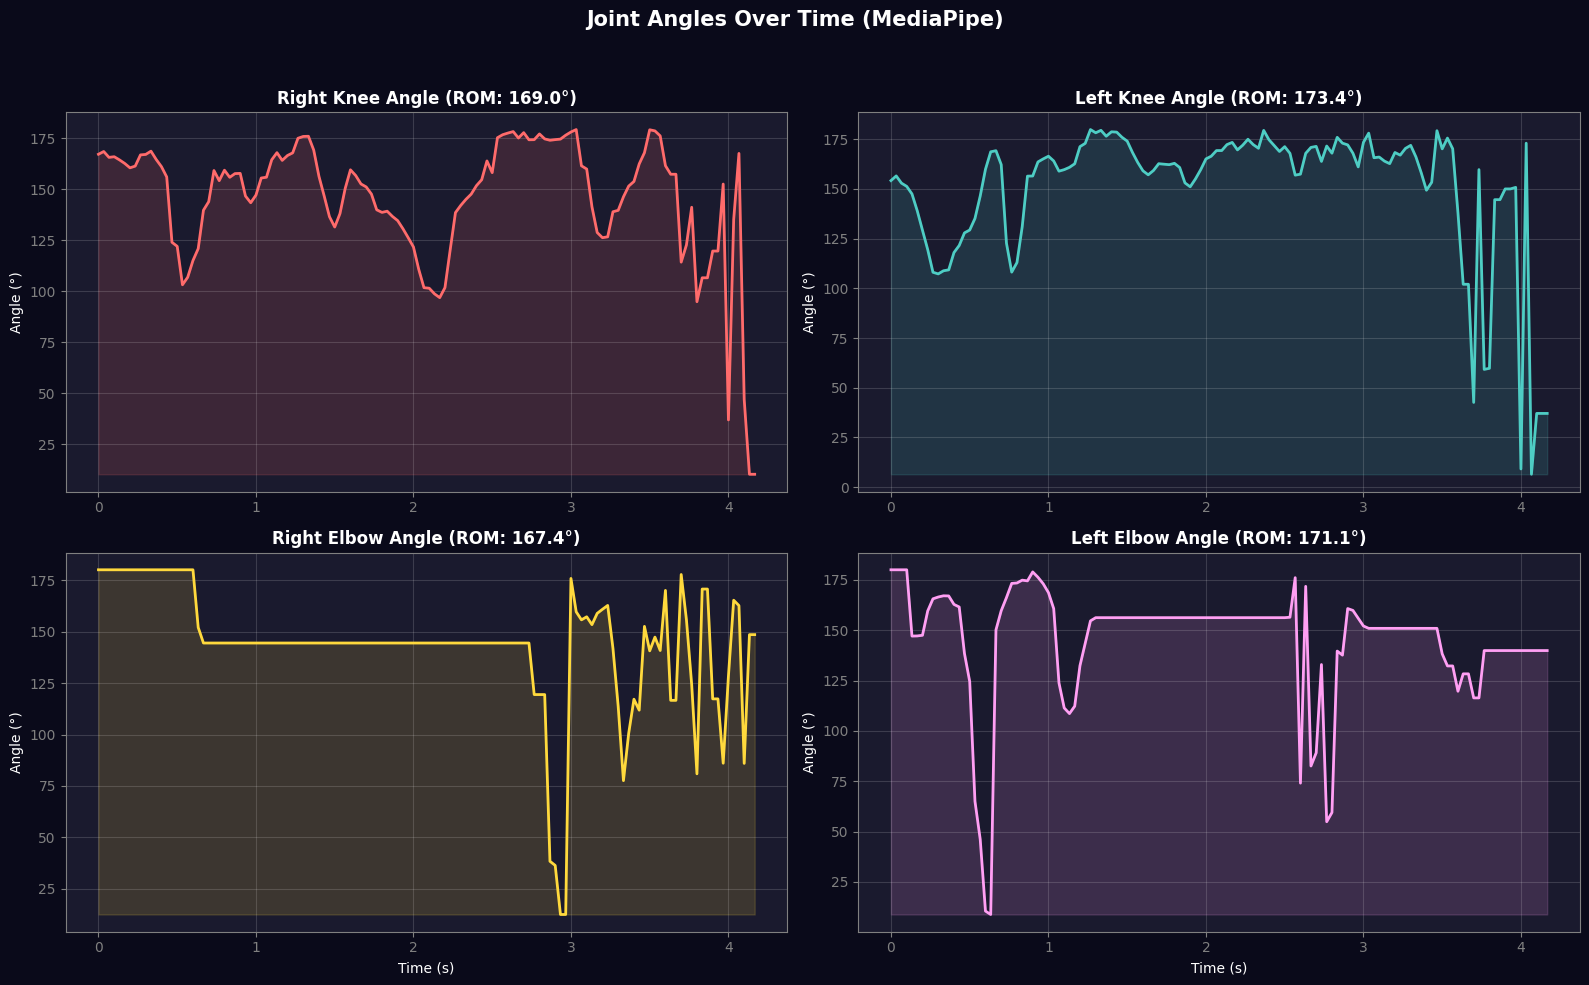


📊 Plot 2: Trunk Inclination & Joint Speeds


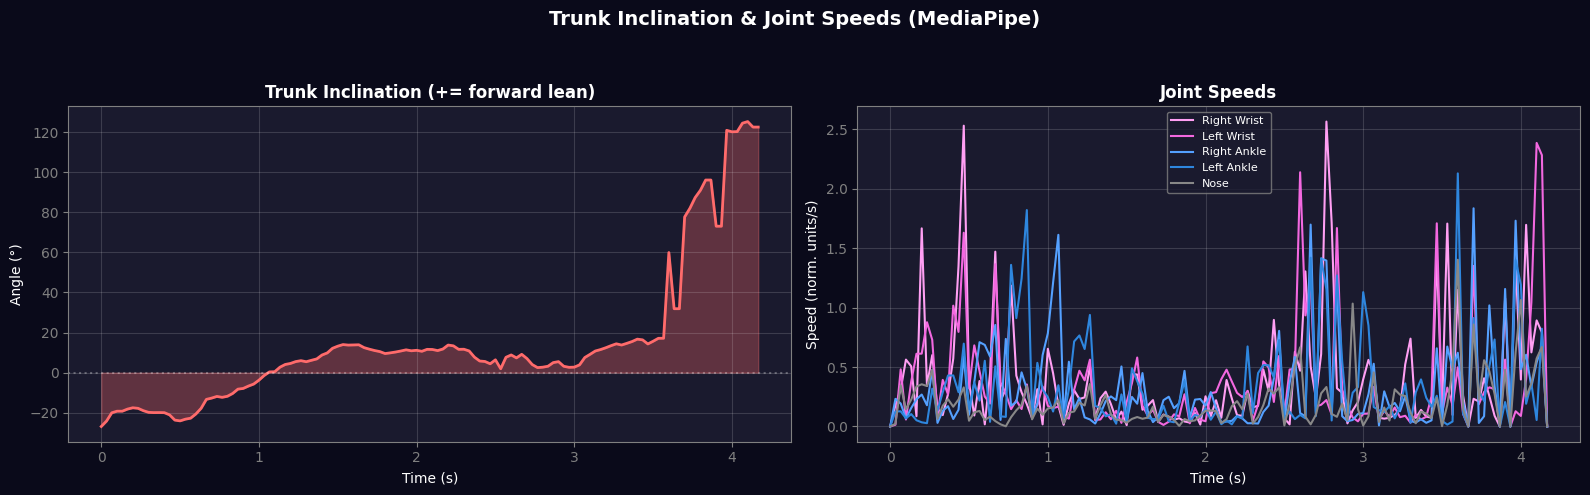


📊 Plot 3: Angular Velocity


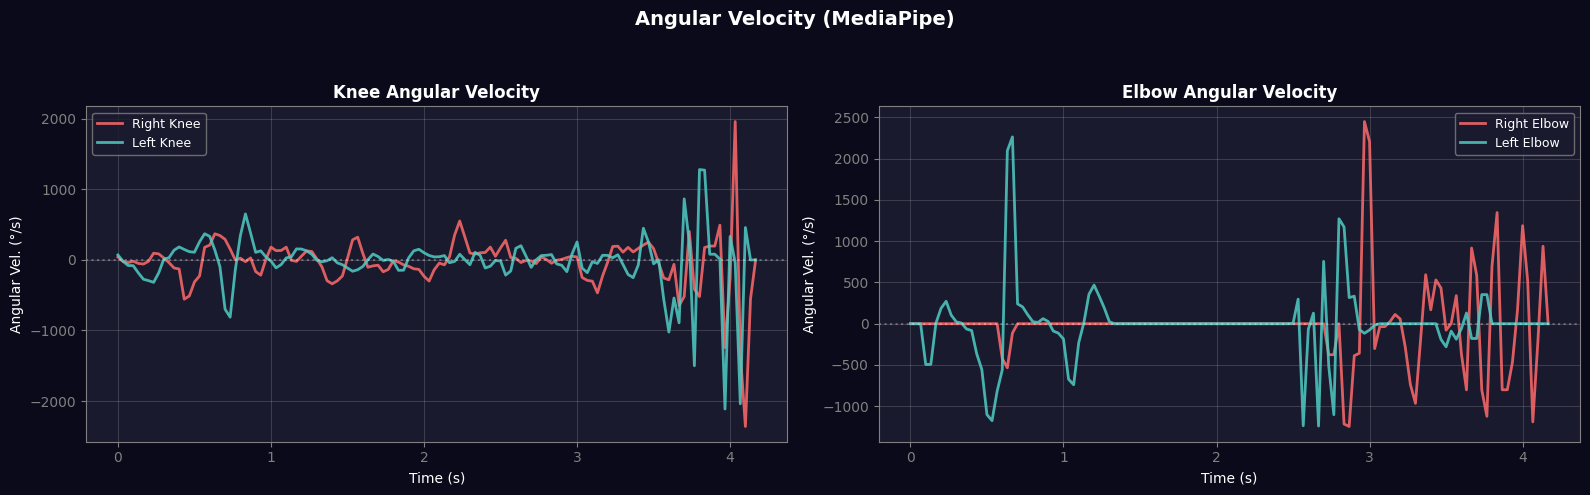


✅ All three plots displayed successfully!


In [19]:
# ============================================================
# Display the three plots
# ============================================================

from IPython.display import Image as IPImage, display
import tempfile

t = all_timestamps
DARK_BG = '#0a0a1a'
PANEL_BG = '#1a1a2e'

# ── Plot 1: Joint angles (knees and elbows) ────────────────────────────
fig, axes = plt.subplots(2,2, figsize=(16,10))
fig.patch.set_facecolor(DARK_BG)

plot_list = [
    ("right_knee",  "Right Knee", '#ff6b6b', 0, 0),
    ("left_knee",   "Left Knee",  '#4ecdc4', 0, 1),
    ("right_elbow", "Right Elbow", '#ffd93d', 1, 0),
    ("left_elbow",  "Left Elbow",  '#ff9ff3', 1, 1),
]

for name, label, color, row, col in plot_list:
    ax = axes[row][col]
    data = all_angles[name]
    ax.plot(t[:len(data)], data, color=color, linewidth=2)
    ax.fill_between(t[:len(data)], min(data), data, alpha=0.15, color=color)
    
    rom = max(data) - min(data)
    ax.set_title(f"{label} Angle (ROM: {rom:.1f}°)", fontsize=12, fontweight='bold', color='white')
    ax.set_ylabel("Angle (°)", color='white')
    ax.set_facecolor(PANEL_BG)
    ax.grid(True, alpha=0.15, color='white')
    ax.tick_params(colors='gray')
    for s in ax.spines.values():
        s.set_color('gray')
        
for ax in axes[1]:
    ax.set_xlabel("Time (s)", color='white')
    
fig.suptitle("Joint Angles Over Time (MediaPipe)", fontsize=15,
             fontweight='bold', color='white')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('plot1_joint_angles.png', dpi=100, facecolor=DARK_BG, bbox_inches='tight')
plt.close()
print("📊 Plot 1: Joint Angles Over Time")
display(IPImage('plot1_joint_angles.png'))


# ── Plot 2: Trunk inclination + Joint speeds ────────────────────────
fig, axes = plt.subplots(1,2, figsize=(16,5))
fig.patch.set_facecolor(DARK_BG)

# Trunk inclination
ax = axes[0]
ax.fill_between(t[:len(all_trunk_incl)], all_trunk_incl, alpha=0.3, color='#ff6b6b')
ax.plot(t[:len(all_trunk_incl)], all_trunk_incl, color='#ff6b6b', linewidth=2)
ax.axhline(y=0, color='white', linestyle=':', alpha=0.3)
ax.set_title("Trunk Inclination (+= forward lean)", fontsize=12, fontweight='bold', color='white')
ax.set_ylabel("Angle (°)", color='white')
ax.set_xlabel("Time (s)", color='white')
ax.set_facecolor(PANEL_BG)
ax.tick_params(colors='gray')
ax.grid(True, alpha=0.15, color='white')
for s in ax.spines.values():
    s.set_color('gray') 

# Joint speeds
ax = axes[1]
speed_colors = {"right_wrist": '#ff9ff3', "left_wrist": '#f368e0',
                "right_ankle": '#54a0ff', "left_ankle": '#2e86de', "nose": '#888888'}
for joint_name, color in speed_colors.items():
    data = all_speeds[joint_name]
    ax.plot(t[:len(data)], data, color=color, linewidth=1.5,
            label=joint_name.replace("_", " ").title())

ax.set_title("Joint Speeds", fontsize=12, fontweight='bold', color='white')
ax.set_ylabel("Speed (norm. units/s)", color='white')
ax.set_xlabel("Time (s)", color='white')
ax.legend(fontsize=8, facecolor=PANEL_BG, edgecolor='gray', labelcolor='white')
ax.set_facecolor(PANEL_BG)
ax.tick_params(colors='gray')
ax.grid(True, alpha=0.15, color='white')
for s in ax.spines.values():
    s.set_color('gray')

fig.suptitle("Trunk Inclination & Joint Speeds (MediaPipe)", fontsize=14,
             fontweight='bold', color='white')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('plot2_trunk_speed.png', dpi=100, facecolor=DARK_BG, bbox_inches='tight')
plt.close()
print("\n📊 Plot 2: Trunk Inclination & Joint Speeds")
display(IPImage('plot2_trunk_speed.png'))

# ── Plot 3: Angular velocities ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(DARK_BG)

for idx, (joints, title) in enumerate([
    (["right_knee", "left_knee"], "Knee Angular Velocity"),
    (["right_elbow", "left_elbow"], "Elbow Angular Velocity"),
]):
    ax = axes[idx]
    colors_iter = ['#ff6b6b', '#4ecdc4']
    for j, (joint, c) in enumerate(zip(joints, colors_iter)):
        data = all_angular_vel[joint]
        ax.plot(t[:len(data)], data, color=c, linewidth=2,
                label=joint.replace("_", " ").title(), alpha=0.85)
    ax.axhline(y=0, color='white', linestyle=':', alpha=0.3)
    ax.set_title(title, color='white', fontsize=12, fontweight='bold')
    ax.set_ylabel("Angular Vel. (°/s)", color='white')
    ax.set_xlabel("Time (s)", color='white')
    ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor='gray', labelcolor='white')
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors='gray')
    ax.grid(True, alpha=0.15, color='white')
    for s in ax.spines.values():
        s.set_color('gray')

fig.suptitle("Angular Velocity (MediaPipe)", fontsize=14, fontweight='bold', color='white')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('plot3_angular_velocity.png', dpi=100, facecolor=DARK_BG, bbox_inches='tight')
plt.close()
print("\n📊 Plot 3: Angular Velocity")
display(IPImage('plot3_angular_velocity.png'))

print("\n✅ All three plots displayed successfully!")


In [20]:
# ============================================================
# Generate an annotated video (for professor submission ★)
# ============================================================
#
# Create a video with the skeleton overlaid on the original video.

print("🎬 Generating annotated video...")

landmarker2 = PoseLandmarker.create_from_options(options)
cap = cv2.VideoCapture(VIDEO_PATH)

out_video_path = os.path.join(OUTPUT_DIR, 'annotated_video.mp4')
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(out_video_path, fourcc, FPS, (WIDTH, HEIGHT))

frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    ts_ms = int(frame_idx * 1000 / FPS)
    res = landmarker2.detect_for_video(mp_img, ts_ms)
    
    if res.pose_landmarks and len(res.pose_landmarks) > 0:
        landmarks = res.pose_landmarks[0]
        
        # Convert keypoint coordinates to pixel coordinates
        kp_px = {}
        for idx, lm in enumerate(landmarks):
            name = KEYPOINT_NAMES[idx]
            px = int(lm.x * WIDTH)
            py = int(lm.y * HEIGHT)
            kp_px[name] = (px, py)
            
        # Draw skeleton
        for (n1, n2) in SKELETON_CONNECTIONS:
            if n1 in kp_px and n2 in kp_px:
                cv2.line(frame, kp_px[n1], kp_px[n2], (0, 255, 180), 2)
        
        # Draw keypoints
        for name, (px, py) in kp_px.items():
            cv2.circle(frame, (px, py), 4, (255, 255, 255), -1)
            cv2.circle(frame, (px, py), 3, (0, 255, 180), -1)
    
    # Frame info text
    cv2.putText(frame, f"Frame: {frame_idx} | t={frame_idx/FPS:.2f}s",
                (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()
landmarker2.close()

print(f"✅ Annotated video saved: {out_video_path}")


🎬 Generating annotated video...
✅ Annotated video saved: C:\Rugby Coaching\output_MediaPipe_tackling\annotated_video.mp4


In [21]:
# ============================================================
# Cell 10: Export to CSV (for professor submission ★)
# ============================================================

csv_path = os.path.join(OUTPUT_DIR, 'analysis_results.csv')

headers = ['frame', 'timestamp_s']
headers += [f"angle_{name}" for name in JOINT_ANGLE_DEFS]
headers += [f"trunk_inclination_deg"]
headers += [f"speed_{name}" for name in speed_joints]
headers += [f"angvel_{name}_deg_per_s" for name in JOINT_ANGLE_DEFS]

with open(csv_path, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(headers)
    
    n = len(all_timestamps)
    for i in range(n):
        row = [i, all_timestamps[i]]
        
        # Angles
        for name in JOINT_ANGLE_DEFS:
            row.append(f"{all_angles[name][i]:.2f}" if i < len(all_angles[name]) else "")
        
        # Trunk inclination
        row.append(f"{all_trunk_incl[i]:.2f}" if i < len(all_trunk_incl) else "")
        
        # Joint speeds
        for name in speed_joints:
            row.append(f"{all_speeds[name][i]:.4f}" if i < len(all_speeds[name]) else "")
        
        # Angular velocities
        for name in JOINT_ANGLE_DEFS:
            row.append(f"{all_angular_vel[name][i]:.2f}" if i < len(all_angular_vel[name]) else "")
        
        writer.writerow(row)

print(f"✅ Analysis results saved to CSV: {csv_path}")
print(f"   Rows: {n + 1} (including header)")
print(f"   Columns: {len(headers)}")
print("\n   You can open this CSV in Excel to review the data.")


✅ Analysis results saved to CSV: C:\Rugby Coaching\output_MediaPipe_tackling\analysis_results.csv
   Rows: 127 (including header)
   Columns: 24

   You can open this CSV in Excel to review the data.
